Сравнение бейзлайна и моделей на 5 отобранных ресторанах и отложенных 6 неделях, выбор финальной модели, её обучение на всей истории и сохранение артефакта для `predict.py`.

Логика очистки/фичей/модели — в `src/`, ноутбук её только вызывает. См. `01_eda.ipynb` для обоснования правил обработки пропусков.

## 1. Imports и paths

In [12]:
from src.data import load_data, load_calendar
from src.cleaning import clean_data
from src.features import build_features, FEATURE_COLUMNS
from src.model import (
    build_preprocessor,
    build_lr_model,
    train_random_forest,
    train_catboost,
    train_prophet,
)
from src.validation import evaluate_predictions
from src.validation import temporal_split

## 2. Датасет

In [13]:
raw_dir = PROJECT_ROOT / "data" / "raw"
processed_path = PROJECT_ROOT / "data" / "processed" / "features.parquet"

calendar = load_calendar(raw_dir)

data = load_data(raw_dir)
data = clean_data(data, calendar)
data = build_features(data, calendar)

processed_path.parent.mkdir(parents=True, exist_ok=True)
data.to_parquet(processed_path, index=False)

print("Shape:", data.shape)

Shape: (296279, 23)


In [14]:
data.isna().sum().sort_values(ascending=False)

guests_lag_28          50406
guests_lag_21          45038
guests_lag_14          39717
guests_lag_7           34392
guests_lag_1           29844
guests                 29015
guests_roll_mean_28    18173
guests_roll_std_28     18173
guests_roll_mean_7      9348
guests_roll_std_7       9348
area                       0
date                       0
restaurant_id              0
genre                      0
is_holiday                 0
day_of_week                0
is_long_gap                0
missing_type               0
is_regular_off             0
is_weekend                 0
month                      0
is_missing                 0
holiday_phase              0
dtype: int64

In [15]:
data.head()

,restaurant_id,date,guests,is_holiday,genre,area,day_of_week,month,is_weekend,is_missing,...,guests_lag_1,guests_lag_7,guests_lag_14,guests_lag_21,guests_lag_28,guests_roll_mean_7,guests_roll_std_7,guests_roll_mean_28,guests_roll_std_28,holiday_phase
0,air_00a91d42b08b08d9,2016-07-01,35.0,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,4,7,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,regular
1,air_00a91d42b08b08d9,2016-07-02,9.0,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,5,7,True,False,...,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,regular
2,air_00a91d42b08b08d9,2016-07-03,0.0,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,6,7,True,True,...,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,regular
3,air_00a91d42b08b08d9,2016-07-04,20.0,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,0,7,False,False,...,0.0,NaN,NaN,NaN,NaN,14.666667,18.175075,NaN,NaN,regular
4,air_00a91d42b08b08d9,2016-07-05,25.0,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,1,7,False,False,...,20.0,NaN,NaN,NaN,NaN,16.000000,15.077577,NaN,NaN,regular


In [16]:
model_data = data[data["guests"].notna()].copy()

print("Model data:", model_data.shape)

Model data: (267264, 23)


In [17]:
#  для Prophet будем считать предсказание только для пяти точек (обучается отдельно по каждому ресторану, затратно считать для всех)
restaurant_stats = (
    model_data.groupby("restaurant_id")["guests"]
    .agg(["count", "mean", "std"])
    .query("count >= 200 and std > 0")
)

experiment_restaurants = (
    restaurant_stats
    .sort_values("count", ascending=False)
    .head(5)
    .index
    .tolist()
)

experiment_data = model_data[
    model_data["restaurant_id"].isin(experiment_restaurants)
].copy()

print(experiment_restaurants)

['air_5c817ef28f236bdf', 'air_a083834e7ffe187e', 'air_36bcf77d3382d36e', 'air_d97dabf7aae60da5', 'air_232dcee6f7c51d37']


## 4. Temporal split

In [18]:
train, valid = temporal_split(
    model_data,
    validation_weeks=6,
)

print(
    "Train:",
    train["date"].min(),
    "—",
    train["date"].max(),
    train.shape,
)

print(
    "Valid:",
    valid["date"].min(),
    "—",
    valid["date"].max(),
    valid.shape,
)

Train: 2016-01-01 00:00:00 — 2017-03-10 00:00:00 (234738, 23)
Valid: 2017-03-11 00:00:00 — 2017-04-22 00:00:00 (32526, 23)


## 5. X, y

In [19]:
X_train = train[FEATURE_COLUMNS].copy()
y_train = train["guests"]

X_valid = valid[FEATURE_COLUMNS].copy()
y_valid = valid["guests"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (234738, 17)
y_train: (234738,)
X_valid: (32526, 17)
y_valid: (32526,)


## 6. Preprocessor

In [20]:
categorical_features = [
    "restaurant_id",
    "genre",
    "area",
    "holiday_phase",
]

numeric_features = [
    "day_of_week",
    "is_weekend",
    "month",
    "is_holiday",
    "guests_lag_1",
    "guests_lag_7",
    "guests_lag_14",
    "guests_lag_21",
    "guests_lag_28",
    "guests_roll_mean_7",
    "guests_roll_std_7",
    "guests_roll_mean_28",
    "guests_roll_std_28",
]

In [21]:
preprocessor = build_preprocessor(
    categorical_features=categorical_features,
    numeric_features=numeric_features,
)

## 7. Naive baseline

In [22]:
baseline_pred = valid["guests_lag_7"]

baseline_mask = baseline_pred.notna()

baseline_metrics = evaluate_predictions(
    y_valid[baseline_mask],
    baseline_pred[baseline_mask],
)

print(baseline_metrics)

{'MAE': 8.900531535619368, 'RMSE': np.float64(15.19392907219219), 'MAPE': np.float64(74.43207498547447)}


## 8. Линейная регрессия (+L2)

In [23]:
ridge_model = build_lr_model(
    preprocessor=preprocessor,
    alpha=1.0,
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_valid)

ridge_metrics = evaluate_predictions(
    y_valid[baseline_mask],
    ridge_pred[baseline_mask],
)

print("Ridge:")
print(ridge_metrics)

Ridge:
{'MAE': 7.494948973788326, 'RMSE': np.float64(11.937211040326355), 'MAPE': np.float64(66.93455582828938)}


## 9. CatBoost

In [24]:
catboost_categorical_features = [
    X_train.columns.get_loc(column)
    for column in categorical_features
]

In [25]:
catboost_model = train_catboost(
    X_train,
    y_train,
    categorical_features=catboost_categorical_features,
)

catboost_pred = catboost_model.predict(X_valid)

catboost_metrics = evaluate_predictions(
    y_valid[baseline_mask],
    catboost_pred[baseline_mask],
)

print("CatBoost:")
print(catboost_metrics)

CatBoost:
{'MAE': 6.885198739768754, 'RMSE': np.float64(11.555182234061123), 'MAPE': np.float64(60.9711191219853)}


## 10. Prophet

In [26]:
train_experiment = train[train["restaurant_id"].isin(experiment_restaurants)]
valid_experiment = valid[valid["restaurant_id"].isin(experiment_restaurants)]

prophet_results = train_prophet(
    train=train,
    forecast_dates=valid["date"],
)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
17:59:42 - cmdstanpy - INFO - Chain [1] start processing
18:05:17 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
prophet_results = prophet_results.rename(columns={"yhat": "prediction"})
prophet_results["actual"] = valid["guests"].values
prophet_results["restaurant_id"] = valid["restaurant_id"].values

prophet_metrics = evaluate_predictions(
    prophet_results["actual"],
    prophet_results["prediction"],
)
print("Prophet")
print(prophet_metrics)



Prophet
{'MAE': 15.088259962228207, 'RMSE': np.float64(19.684278834793584), 'MAPE': np.float64(193.79328835426927)}


## 12. Сводная таблица

In [35]:
ridge_metrics_full = evaluate_predictions(y_valid, ridge_pred)
catboost_metrics_full = evaluate_predictions(y_valid, catboost_pred)

results = pd.DataFrame([
    {
        "model": "Naive lag-7",
        "MAE_with_nan": None, "RMSE_with_nan": None,
        "MAE_no_nan": baseline_metrics["MAE"], "RMSE_no_nan": baseline_metrics["RMSE"],
    },
    {
        "model": "LR",
        "MAE_with_nan": ridge_metrics_full["MAE"], "RMSE_with_nan": ridge_metrics_full["RMSE"],
        "MAE_no_nan": ridge_metrics["MAE"], "RMSE_no_nan": ridge_metrics["RMSE"],
    },
    {
        "model": "CatBoost",
        "MAE_with_nan": catboost_metrics_full["MAE"], "RMSE_with_nan": catboost_metrics_full["RMSE"],
        "MAE_no_nan": catboost_metrics["MAE"], "RMSE_no_nan": catboost_metrics["RMSE"],
    },
    {
        "model": "Prophet",
        "MAE_with_nan": prophet_metrics["MAE"], "RMSE_with_nan": prophet_metrics["RMSE"],
        "MAE_no_nan": prophet_metrics["MAE"], "RMSE_no_nan": prophet_metrics["RMSE"],
    },
])

results = results.sort_values("MAE_no_nan").round(2).reset_index(drop=True)
results


,model,MAE_with_nan,RMSE_with_nan,MAE_no_nan,RMSE_no_nan
0,CatBoost,6.88,11.59,6.89,11.56
1,LR,7.52,11.98,7.49,11.94
2,Naive lag-7,NaN,NaN,8.90,15.19
3,Prophet,15.09,19.68,15.09,19.68


## Финальная модель
CatBoost — лучший результат по MAE на валидации

Какие признаки CatBoost использует сильнее всего для прогноза `guests`.

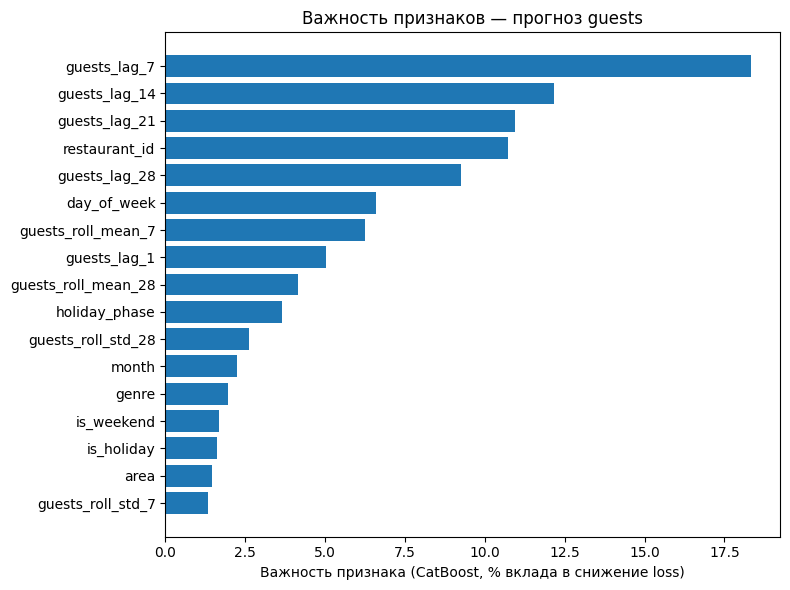

In [36]:
import matplotlib.pyplot as plt

importances = pd.Series(
    catboost_model.get_feature_importance(),
    index=FEATURE_COLUMNS,
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values)
plt.xlabel("Важность признака (CatBoost, % вклада в снижение loss)")
plt.title("Важность признаков — прогноз guests")
plt.tight_layout()
plt.show()

Лаги и скользящие статистики (`guests_lag_7`, `guests_roll_mean_7/28`) несут основной вес — модель в первую очередь опирается на недавнюю историю самого ресторана, а `restaurant_id`/`genre` задают его базовый уровень посещаемости. Календарные признаки (`month`, `holiday_phase`) вносят заметно меньше — ожидаемо для 15 месяцев данных без полного годового цикла.